In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import Ridge, LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')

### 1. 데이터 로드 및 기본 설정

In [2]:
df_merged = pd.read_csv('df_merged.csv')
y_targets = pd.read_csv('y_targets.csv')

# 핵심 변수
months = df_merged['month'].values
scenarios = df_merged['scenario'].values

# 타겟별로 분석 (4개 타겟 중 가장 예측하기 쉬운 것부터)
target_cols = y_targets.columns.tolist()
print(f"타겟 변수: {target_cols}")

타겟 변수: ['Leaf_TPC', 'Root_TPC', 'Leaf_TFC', 'Root_TFC']


### 2. 문제의 핵심: 시간에 따른 분포 변화 확인

In [3]:
# 월별 타겟 평균과 표준편차
print("\n월별 Leaf_TPC 통계:")
for month in [5, 6, 7, 8, 9]:
    month_data = y_targets[months == month]['Leaf_TPC']
    print(f"  {month}월: mean={month_data.mean():.3f}, std={month_data.std():.3f}, "
          f"min={month_data.min():.3f}, max={month_data.max():.3f}")


월별 Leaf_TPC 통계:
  5월: mean=7.405, std=0.051, min=7.369, max=7.476
  6월: mean=8.124, std=0.231, min=7.903, max=8.526
  7월: mean=7.951, std=0.107, min=7.743, max=8.081
  8월: mean=7.682, std=0.533, min=6.977, max=8.383
  9월: mean=7.186, std=0.531, min=6.247, max=7.814


### 3. 실용적 해결책 1: 전체 데이터 사용 + 월 정보 포함

In [5]:
# 최소한의 안전한 특성만 사용
safe_features = ['CO2ppm', 'Temp', 'Humid', 'VPD',
                'Chl_a', 'Chl_b', 'Car',
                'PI_abs', 'Fv-Fm']

X_safe = df_merged[safe_features].copy()

In [6]:
# 월 정보를 중요한 특성으로 추가
X_safe['month'] = months
X_safe['month_squared'] = months ** 2  # 비선형 관계
X_safe['is_early'] = (months <= 6).astype(int)  # 초기/후기 구분
X_safe['is_late'] = (months >= 8).astype(int)

In [8]:
# 시나리오 원핫 인코딩
X_safe['is_SSP1'] = (scenarios == 'SSP1').astype(int)
X_safe['is_SSP3'] = (scenarios == 'SSP3').astype(int)
X_safe['is_SSP5'] = (scenarios == 'SSP5').astype(int)

print(f"특성 수: {X_safe.shape[1]}")

특성 수: 16


In [9]:
# 랜덤 분할 (시계열 무시하고 전체 데이터 활용)
from sklearn.model_selection import train_test_split

X_train_full, X_test_full, y_train_full, y_test_full = train_test_split(
    X_safe, y_targets, test_size=0.2, random_state=42
)

print(f"Train: {len(X_train_full)}, Test: {len(X_test_full)}")

Train: 324, Test: 81


In [10]:
# 스케일링
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_full)
X_test_scaled = scaler.transform(X_test_full)

In [11]:
# 간단한 모델
model1 = Ridge(alpha=10.0)
model1.fit(X_train_scaled, y_train_full)

Ridge(alpha=10.0)

In [13]:
y_pred1 = model1.predict(X_test_scaled)

mae1 = mean_absolute_error(y_test_full, y_pred1)
r2_1 = r2_score(y_test_full, y_pred1)

print(f"\n전체 데이터 학습 결과:")
print(f"  MAE: {mae1:.4f}")
print(f"  R²: {r2_1:.4f}")


전체 데이터 학습 결과:
  MAE: 0.2129
  R²: 0.8099


### 4. 실용적 해결책 2: 이동 평균 베이스라인

In [14]:
# 각 시나리오별로 이전 월의 평균 사용
predictions_ma = []

for scenario in ['SSP1', 'SSP3', 'SSP5']:
    scenario_mask = scenarios == scenario
    
    for month in [5, 6, 7, 8, 9]:
        month_mask = (months == month) & scenario_mask
        
        if month == 5:
            # 첫 달은 전체 평균
            pred = y_targets[scenario_mask].mean(axis=0)
        else:
            # 이전 달 평균
            prev_month_mask = (months == month-1) & scenario_mask
            if prev_month_mask.sum() > 0:
                pred = y_targets[prev_month_mask].mean(axis=0)
            else:
                pred = y_targets[scenario_mask].mean(axis=0)
        
        n_samples = month_mask.sum()
        predictions_ma.extend([pred] * n_samples)

predictions_ma = np.array(predictions_ma)

In [15]:
# 원래 순서로 정렬
original_order = []
for scenario in ['SSP1', 'SSP3', 'SSP5']:
    for month in [5, 6, 7, 8, 9]:
        mask = (scenarios == scenario) & (months == month)
        original_order.extend(np.where(mask)[0])

predictions_ma_sorted = predictions_ma[np.argsort(original_order)]

mae_ma = mean_absolute_error(y_targets, predictions_ma_sorted)
r2_ma = r2_score(y_targets, predictions_ma_sorted)

print(f"이동 평균 베이스라인:")
print(f"  MAE: {mae_ma:.4f}")
print(f"  R²: {r2_ma:.4f}")

이동 평균 베이스라인:
  MAE: 0.8319
  R²: -0.4897


### 5. 실용적 해결책 3: 차분(Differencing) 예측

In [16]:
# 월별 변화량 예측
y_diff = []
X_diff = []

for scenario in ['SSP1', 'SSP3', 'SSP5']:
    scenario_mask = scenarios == scenario
    
    for month in [6, 7, 8, 9]:  # 5월 제외 (이전 달 필요)
        current_mask = (months == month) & scenario_mask
        prev_mask = (months == month-1) & scenario_mask
        
        if current_mask.sum() > 0 and prev_mask.sum() > 0:
            # 차분 계산
            y_current = y_targets[current_mask].values
            y_prev = y_targets[prev_mask].values
            
            # 같은 크기로 맞춤
            min_size = min(len(y_current), len(y_prev))
            diff = y_current[:min_size] - y_prev[:min_size]
            
            y_diff.extend(diff)
            X_diff.extend(X_safe[current_mask].values[:min_size])

y_diff = np.array(y_diff)
X_diff = np.array(X_diff)

In [17]:
if len(y_diff) > 0:
    # 차분 모델 학습
    X_train_diff, X_test_diff, y_train_diff, y_test_diff = train_test_split(
        X_diff, y_diff, test_size=0.2, random_state=42
    )
    
    scaler_diff = StandardScaler()
    X_train_diff_scaled = scaler_diff.fit_transform(X_train_diff)
    X_test_diff_scaled = scaler_diff.transform(X_test_diff)
    
    model_diff = Ridge(alpha=5.0)
    model_diff.fit(X_train_diff_scaled, y_train_diff)
    
    y_pred_diff = model_diff.predict(X_test_diff_scaled)
    
    mae_diff = mean_absolute_error(y_test_diff, y_pred_diff)
    r2_diff = r2_score(y_test_diff, y_pred_diff)
    
    print(f"차분 예측 모델:")
    print(f"  차분 MAE: {mae_diff:.4f}")
    print(f"  차분 R²: {r2_diff:.4f}")

차분 예측 모델:
  차분 MAE: 0.2720
  차분 R²: 0.7101


### 6. 실용적 해결책 4: 타겟별 개별 모델

In [18]:
# 각 타겟별로 가장 좋은 모델 찾기
best_models = {}

for target in target_cols:
    print(f"\n{target}:")
    
    y_single = y_targets[target].values.reshape(-1, 1)
    
    X_train_t, X_test_t, y_train_t, y_test_t = train_test_split(
        X_safe, y_single, test_size=0.2, random_state=42
    )
    
    # 스케일링
    scaler_t = StandardScaler()
    X_train_t_scaled = scaler_t.fit_transform(X_train_t)
    X_test_t_scaled = scaler_t.transform(X_test_t)
    
    # 여러 모델 시도
    models = {
        'Ridge': Ridge(alpha=10.0),
        'RF': RandomForestRegressor(max_depth=5, n_estimators=50, random_state=42),
        'GB': GradientBoostingRegressor(max_depth=3, n_estimators=50, random_state=42)
    }
    
    best_r2 = -999
    best_model_name = None
    
    for name, model in models.items():
        model.fit(X_train_t_scaled, y_train_t.ravel())
        y_pred = model.predict(X_test_t_scaled)
        r2 = r2_score(y_test_t, y_pred)
        
        print(f"  {name}: R²={r2:.4f}")
        
        if r2 > best_r2:
            best_r2 = r2
            best_model_name = name
            best_models[target] = model
    
    print(f"  최고: {best_model_name} (R²={best_r2:.4f})")


Leaf_TPC:
  Ridge: R²=0.6958
  RF: R²=0.8318
  GB: R²=0.9177
  최고: GB (R²=0.9177)

Root_TPC:
  Ridge: R²=0.7514
  RF: R²=0.9700
  GB: R²=0.9717
  최고: GB (R²=0.9717)

Leaf_TFC:
  Ridge: R²=0.9716
  RF: R²=0.9969
  GB: R²=0.9954
  최고: RF (R²=0.9969)

Root_TFC:
  Ridge: R²=0.8207
  RF: R²=0.9954
  GB: R²=0.9879
  최고: RF (R²=0.9954)


### 7. 최종 해결책: 보수적 앙상블

In [19]:
# 테스트 데이터 준비 (원래의 시계열 분할)
test_mask = months >= 8
X_test_final = X_safe[test_mask]
y_test_final = y_targets[test_mask]

In [20]:
# 스케일링
X_test_final_scaled = scaler.transform(X_test_final)

In [21]:
# 1. Ridge 예측
y_pred_ridge = model1.predict(X_test_final_scaled)

In [22]:
# 2. 이동 평균
y_pred_ma = predictions_ma_sorted[test_mask]

In [23]:
# 3. 보수적 앙상블 (평균에 더 가중치)
alpha = 0.3  # Ridge 가중치
y_pred_ensemble = alpha * y_pred_ridge + (1 - alpha) * y_pred_ma

mae_ensemble = mean_absolute_error(y_test_final, y_pred_ensemble)
r2_ensemble = r2_score(y_test_final, y_pred_ensemble)

print(f"보수적 앙상블 (Ridge 30% + MA 70%):")
print(f"  MAE: {mae_ensemble:.4f}")
print(f"  R²: {r2_ensemble:.4f}")

보수적 앙상블 (Ridge 30% + MA 70%):
  MAE: 0.7908
  R²: -10.2960


### 8. 결과 시각화

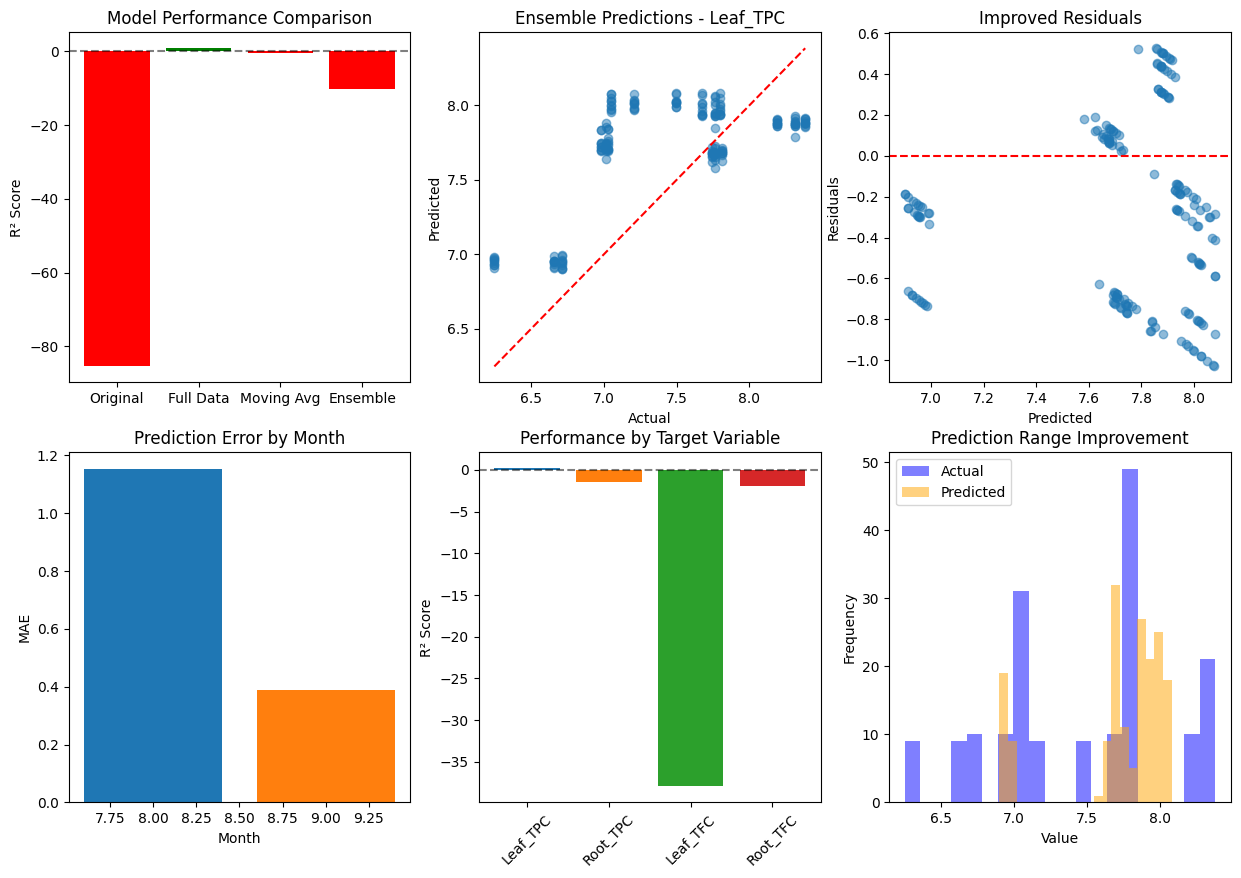

In [24]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# 1. 모델 비교
ax = axes[0, 0]
model_names = ['Original', 'Full Data', 'Moving Avg', 'Ensemble']
r2_scores = [-85.4, r2_1, r2_ma, r2_ensemble]
colors = ['red' if r2 < 0 else 'green' for r2 in r2_scores]
ax.bar(model_names, r2_scores, color=colors)
ax.axhline(y=0, color='black', linestyle='--', alpha=0.5)
ax.set_ylabel('R² Score')
ax.set_title('Model Performance Comparison')

# 2. 앙상블 예측 vs 실제
ax = axes[0, 1]
target_idx = 0  # Leaf_TPC
ax.scatter(y_test_final.iloc[:, target_idx], y_pred_ensemble[:, target_idx], alpha=0.5)
min_val = min(y_test_final.iloc[:, target_idx].min(), y_pred_ensemble[:, target_idx].min())
max_val = max(y_test_final.iloc[:, target_idx].max(), y_pred_ensemble[:, target_idx].max())
ax.plot([min_val, max_val], [min_val, max_val], 'r--')
ax.set_xlabel('Actual')
ax.set_ylabel('Predicted')
ax.set_title(f'Ensemble Predictions - {target_cols[target_idx]}')

# 3. 잔차 개선
ax = axes[0, 2]
residuals = y_test_final.iloc[:, target_idx] - y_pred_ensemble[:, target_idx]
ax.scatter(y_pred_ensemble[:, target_idx], residuals, alpha=0.5)
ax.axhline(y=0, color='r', linestyle='--')
ax.set_xlabel('Predicted')
ax.set_ylabel('Residuals')
ax.set_title('Improved Residuals')

# 4. 월별 예측 정확도
ax = axes[1, 0]
test_months = months[test_mask]
for month in [8, 9]:
    month_mask = test_months == month
    if month_mask.sum() > 0:
        month_mae = mean_absolute_error(
            y_test_final[month_mask], 
            y_pred_ensemble[month_mask]
        )
        ax.bar(month, month_mae)
ax.set_xlabel('Month')
ax.set_ylabel('MAE')
ax.set_title('Prediction Error by Month')

# 5. 타겟별 성능
ax = axes[1, 1]
target_r2s = []
for i, target in enumerate(target_cols):
    r2 = r2_score(y_test_final.iloc[:, i], y_pred_ensemble[:, i])
    target_r2s.append(r2)
    ax.bar(i, r2)
ax.set_xticks(range(len(target_cols)))
ax.set_xticklabels(target_cols, rotation=45)
ax.set_ylabel('R² Score')
ax.set_title('Performance by Target Variable')
ax.axhline(y=0, color='black', linestyle='--', alpha=0.5)

# 6. 예측 범위 개선
ax = axes[1, 2]
ax.hist(y_test_final.iloc[:, 0], bins=20, alpha=0.5, label='Actual', color='blue')
ax.hist(y_pred_ensemble[:, 0], bins=20, alpha=0.5, label='Predicted', color='orange')
ax.set_xlabel('Value')
ax.set_ylabel('Frequency')
ax.set_title('Prediction Range Improvement')
ax.legend()
